# Sistema de Puntos McDonald's — TIEMPO REAL (Solución Propuesta)

Todos los clientes ganan puntos a la misma tasa: **10 puntos por cada $1 gastado**. Los puntos se acreditan en segundos mediante un procesador de eventos.

---

## 1. Librerías y parámetros

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

np.random.seed(42)

N_CLIENTES    = 120
N_TRANSAC     = 600
INICIO        = datetime(2024, 4, 1)
FIN           = datetime(2024, 4, 30, 23, 59)
PUNTOS_X_PESO = 10   # tasa fija para todos los clientes

MC_ROJO     = '#DA291C'
MC_AMARILLO = '#FFC72C'
MC_GRIS     = '#27251F'
MC_CLARO    = '#F5F0E8'

## 2. Datos sintéticos

In [8]:
# Clientes: todos con la misma tasa de puntos
clientes = pd.DataFrame({
    'cliente_id': range(1, N_CLIENTES + 1),
    'nombre'    : [f'Cliente_{i:03d}' for i in range(1, N_CLIENTES + 1)],
})

# Transacciones distribuidas aleatoriamente durante abril 2024
seg_totales = int((FIN - INICIO).total_seconds())

transacciones = pd.DataFrame({
    'tx_id'     : range(1, N_TRANSAC + 1),
    'cliente_id': np.random.choice(clientes['cliente_id'], size=N_TRANSAC),
    'monto'     : np.round(np.random.exponential(scale=8, size=N_TRANSAC) + 2, 2),
    'timestamp' : [
        INICIO + timedelta(seconds=int(s))
        for s in np.random.randint(0, seg_totales, N_TRANSAC)
    ],
})

transacciones = transacciones.sort_values('timestamp').reset_index(drop=True)
transacciones['puntos'] = np.floor(transacciones['monto'] * PUNTOS_X_PESO).astype(int)

print(f'Clientes: {len(clientes)} | Transacciones: {len(transacciones)}')
print(transacciones.head())

Clientes: 120 | Transacciones: 600
   tx_id  cliente_id  monto           timestamp  puntos
0    262          39   6.93 2024-04-01 03:08:23      69
1    531          58   5.79 2024-04-01 05:32:55      57
2    434           4  50.57 2024-04-01 06:13:51     505
3    578          62  10.24 2024-04-01 07:15:55     102
4    520          32  17.77 2024-04-01 08:46:25     177


## 3. Limpieza de datos

In [9]:
n_antes = len(transacciones)

transacciones = transacciones[transacciones['monto'] > 0]
transacciones = transacciones[
    (transacciones['timestamp'] >= INICIO) &
    (transacciones['timestamp'] <= FIN)
]
transacciones = transacciones.drop_duplicates(subset='tx_id').reset_index(drop=True)

print(f'Registros antes: {n_antes} | Después: {len(transacciones)} | Eliminados: {n_antes - len(transacciones)}')

Registros antes: 600 | Después: 600 | Eliminados: 0


## 4. Sistema en TIEMPO REAL

Cada transacción dispara un evento. El procesador lo recibe, calcula los puntos y actualiza el saldo del cliente en 1–10 segundos.

In [10]:
# Latencia de procesamiento: 1 a 10 segundos por evento
latencia_seg = np.random.randint(1, 11, size=len(transacciones))

transacciones['disponible'] = [
    ts + timedelta(seconds=int(lag))
    for ts, lag in zip(transacciones['timestamp'], latencia_seg)
]

transacciones['latencia_seg'] = latencia_seg

print(f"Latencia media : {transacciones['latencia_seg'].mean():.1f} s")
print(f"Latencia máxima: {transacciones['latencia_seg'].max()} s")
print(f"Latencia mínima: {transacciones['latencia_seg'].min()} s")

Latencia media : 5.5 s
Latencia máxima: 10 s
Latencia mínima: 1 s


## 5. Visualización

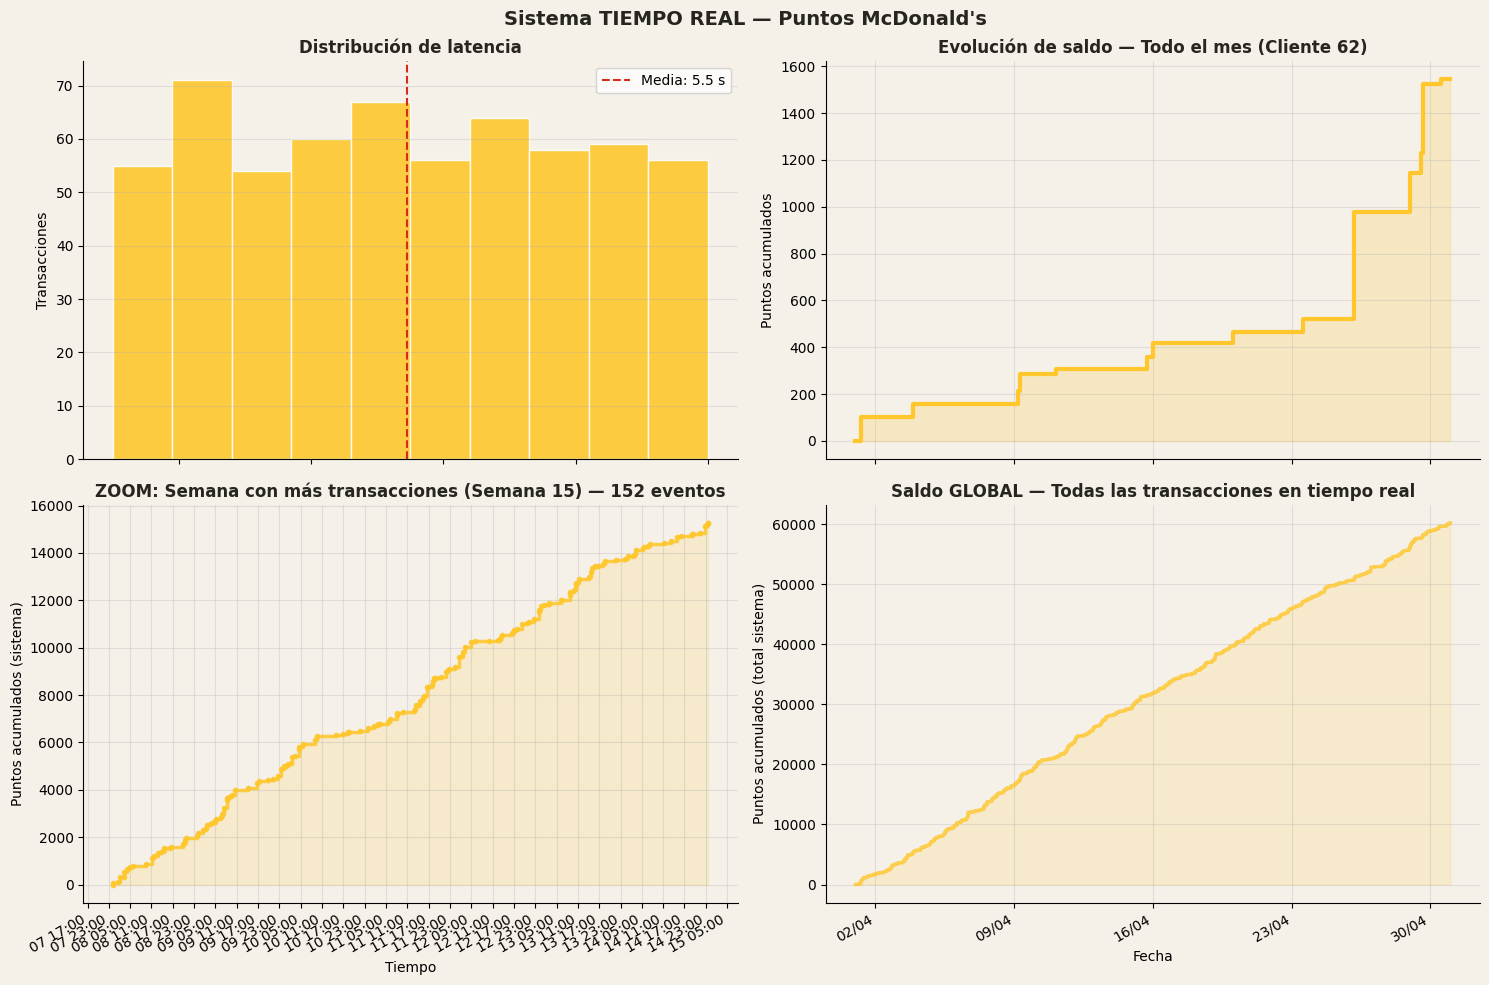

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor(MC_CLARO)
fig.suptitle('Sistema TIEMPO REAL — Puntos McDonald\'s', fontweight='bold', color=MC_GRIS, fontsize=14)

# Gráfica 1: distribución de latencia en segundos
ax1 = axes[0, 0]
ax1.set_facecolor(MC_CLARO)
ax1.hist(transacciones['latencia_seg'], bins=10, color=MC_AMARILLO, edgecolor='white', alpha=0.9)
ax1.axvline(transacciones['latencia_seg'].mean(), color=MC_ROJO, linestyle='--',
            label=f"Media: {transacciones['latencia_seg'].mean():.1f} s")
ax1.set_title('Distribución de latencia', color=MC_GRIS, fontweight='bold')
ax1.set_xlabel('Segundos de espera para ver los puntos')
ax1.set_ylabel('Transacciones')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Gráfica 2: evolución del saldo completo (todo el mes)
ax2 = axes[0, 1]
ax2.set_facecolor(MC_CLARO)
cliente_ej = transacciones.groupby('cliente_id')['tx_id'].count().idxmax()
tx_ej = transacciones[transacciones['cliente_id'] == cliente_ej].sort_values('disponible').copy()

saldo_rt = (
    tx_ej.groupby('disponible')['puntos'].sum()
    .reset_index().sort_values('disponible')
)
saldo_rt['saldo'] = saldo_rt['puntos'].cumsum()

tiempos = [INICIO] + list(saldo_rt['disponible']) + [FIN]
saldos  = [0] + list(saldo_rt['saldo']) + [saldo_rt['saldo'].iloc[-1]]
ax2.step(tiempos, saldos, where='post', color=MC_AMARILLO, linewidth=3)
ax2.fill_between(tiempos, saldos, step='post', alpha=0.2, color=MC_AMARILLO)
ax2.set_title(f'Evolución de saldo — Todo el mes (Cliente {cliente_ej})', color=MC_GRIS, fontweight='bold')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Puntos acumulados')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator())
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

# Gráfica 3: zoom en UNA SEMANA con MUCHAS transacciones
# Encontrar la semana con más transacciones en TODO EL SISTEMA
transacciones['semana'] = transacciones['disponible'].dt.isocalendar().week
transacciones['año'] = transacciones['disponible'].dt.isocalendar().year
semana_mas_tx = transacciones.groupby('semana').size().idxmax()
tx_semana_todos = transacciones[transacciones['semana'] == semana_mas_tx].sort_values('disponible').copy()

# Obtener las fechas límite de esa semana
inicio_semana_real = tx_semana_todos['disponible'].min()
fin_semana_real = tx_semana_todos['disponible'].max()

ax3 = axes[1, 0]
ax3.set_facecolor(MC_CLARO)

# Mostrar todos los puntos acumulados en esa semana en tiempo real
tx_semana_todos['saldo_semana'] = tx_semana_todos['puntos'].cumsum()

tiempos_sem = [inicio_semana_real] + list(tx_semana_todos['disponible']) + [fin_semana_real]
saldos_sem  = [0] + list(tx_semana_todos['saldo_semana']) + [tx_semana_todos['saldo_semana'].iloc[-1]]
ax3.step(tiempos_sem, saldos_sem, where='post', color=MC_AMARILLO, linewidth=2.5, marker='o', markersize=3, alpha=0.85)
ax3.fill_between(tiempos_sem, saldos_sem, step='post', alpha=0.15, color=MC_AMARILLO)

ax3.set_title(f'ZOOM: Semana con más transacciones (Semana {semana_mas_tx}) — {len(tx_semana_todos)} eventos', 
              color=MC_GRIS, fontweight='bold')
ax3.set_xlabel('Tiempo')
ax3.set_ylabel('Puntos acumulados (sistema)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %H:%M'))
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax3.grid(alpha=0.3)
ax3.spines[['top', 'right']].set_visible(False)
fig.autofmt_xdate()

# Gráfica 4: comparación de todas las transacciones ordenadas en tiempo real
ax4 = axes[1, 1]
ax4.set_facecolor(MC_CLARO)
# Mostrar acumulado global de TODAS las transacciones en tiempo real
todas_tx = transacciones.copy().sort_values('disponible')
todas_tx['saldo_global'] = todas_tx['puntos'].cumsum()

tiempos_todas = [INICIO] + list(todas_tx['disponible']) + [FIN]
saldos_todas = [0] + list(todas_tx['saldo_global']) + [todas_tx['saldo_global'].iloc[-1]]
ax4.step(tiempos_todas, saldos_todas, where='post', color=MC_AMARILLO, linewidth=2.5, alpha=0.8)
ax4.fill_between(tiempos_todas, saldos_todas, step='post', alpha=0.15, color=MC_AMARILLO)
ax4.set_title('Saldo GLOBAL — Todas las transacciones en tiempo real', color=MC_GRIS, fontweight='bold')
ax4.set_xlabel('Fecha')
ax4.set_ylabel('Puntos acumulados (total sistema)')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax4.xaxis.set_major_locator(mdates.WeekdayLocator())
ax4.grid(alpha=0.3)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('tiempo_real_resultados.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Resumen

In [12]:
LATENCIA_BATCH_H = 12.0  # referencia del sistema batch (~12 h de media)
factor = (LATENCIA_BATCH_H * 3600) / transacciones['latencia_seg'].mean()

print('=== SISTEMA TIEMPO REAL ===')
print(f"Transacciones  : {len(transacciones)}")
print(f"Clientes activos: {transacciones['cliente_id'].nunique()}")
print(f"Puntos emitidos : {transacciones['puntos'].sum():,}")
print(f"Latencia media  : {transacciones['latencia_seg'].mean():.1f} s")
print(f"Latencia máxima : {transacciones['latencia_seg'].max()} s")
print()
print(f'El sistema RT es ~{factor:.0f}x más rápido que el batch.')

=== SISTEMA TIEMPO REAL ===
Transacciones  : 600
Clientes activos: 119
Puntos emitidos : 60,176
Latencia media  : 5.5 s
Latencia máxima : 10 s

El sistema RT es ~7919x más rápido que el batch.
